
GENERALIZED SIMON'S ALGORITHM
Secret string : 1101
Number of qubits : 4
Number of shots : 5000

|-> QUANTUM CIRCUIT
     ┌───┐                    ┌───┐        ┌─┐      
x_0: ┤ H ├──■──────────────■──┤ H ├────────┤M├──────
     ├───┤  │              │  ├───┤        └╥┘┌─┐   
x_1: ┤ H ├──┼─────────■────┼──┤ H ├─────────╫─┤M├───
     ├───┤  │         │    │  ├───┤┌─┐      ║ └╥┘   
x_2: ┤ H ├──┼────■────┼────┼──┤ H ├┤M├──────╫──╫────
     ├───┤  │    │    │    │  └───┘└╥┘┌───┐ ║  ║ ┌─┐
x_3: ┤ H ├──┼────┼────┼────┼────■───╫─┤ H ├─╫──╫─┤M├
     └───┘┌─┴─┐  │  ┌─┴─┐  │    │   ║ └───┘ ║  ║ └╥┘
y_0: ─────┤ X ├──┼──┤ X ├──┼────┼───╫───────╫──╫──╫─
          └───┘┌─┴─┐└───┘  │    │   ║       ║  ║  ║ 
y_1: ──────────┤ X ├───────┼────┼───╫───────╫──╫──╫─
               └───┘     ┌─┴─┐┌─┴─┐ ║       ║  ║  ║ 
y_2: ────────────────────┤ X ├┤ X ├─╫───────╫──╫──╫─
                         └───┘└───┘ ║       ║  ║  ║ 
y_3: ───────────────────────────────╫───────╫──╫──╫─
                                   

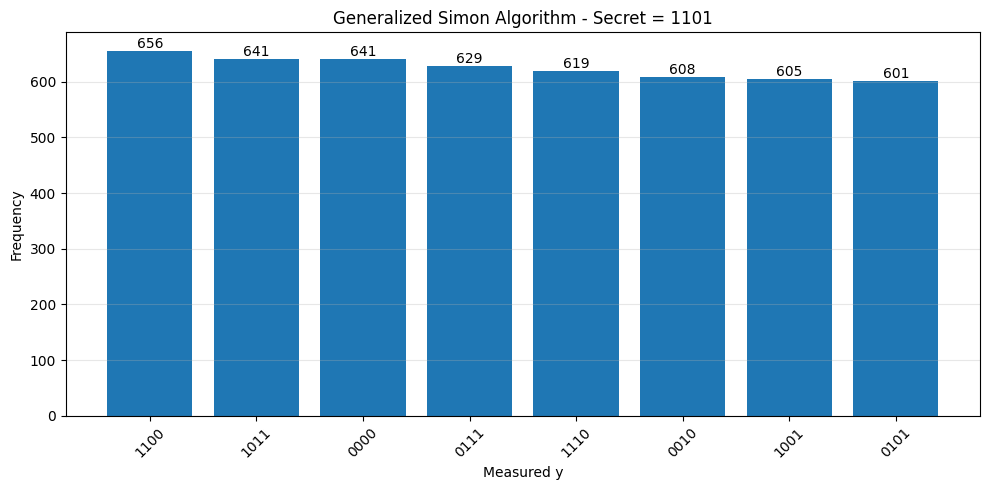

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler

SECRET = "1101"
SHOTS = 5000

N = len(SECRET)

if any(bit not in "01" for bit in SECRET):
    raise ValueError("Secret string must contain only 0 and 1.")

def gf2_rank(matrix, n=None):
    if matrix is None or len(matrix) == 0:
        return 0

    matrix = np.array(matrix, dtype=np.uint8)

    if matrix.ndim == 1:
        matrix = matrix.reshape(1, -1)

    rows, cols = matrix.shape
    rank = 0

    for col in range(cols):
        pivot = None

        for row in range(rank, rows):
            if matrix[row, col] == 1:
                pivot = row
                break

        if pivot is None:
            continue

        matrix[[rank, pivot]] = matrix[[pivot, rank]]

        for row in range(rows):
            if row != rank and matrix[row, col] == 1:
                matrix[row] ^= matrix[rank]

        rank += 1

        if rank == rows:
            break

    return rank

def dot_gf2(a, b):
    result = 0

    for x, y in zip(a, b):
        result ^= (x & y)

    return result

def create_oracle_matrix(secret):
    n = len(secret)
    secret_bits = [int(bit) for bit in secret]

    if all(bit == 0 for bit in secret_bits):
        return np.eye(n, dtype=np.uint8)

    pivot = secret_bits.index(1)

    rows = []

    for j in range(n):
        if j == pivot:
            continue

        row = np.zeros(n, dtype=np.uint8)

        row[j] = 1
        row[pivot] = secret_bits[j]

        rows.append(row)

    return np.array(rows, dtype=np.uint8)

def build_simon_circuit(secret):
    n = len(secret)

    x = QuantumRegister(n, "x")
    y = QuantumRegister(n, "y")
    c = ClassicalRegister(n, "c")

    qc = QuantumCircuit(x, y, c)

    qc.h(x)

    A = create_oracle_matrix(secret)

    rows = A.shape[0]

    for output_bit in range(rows):
        for input_bit in range(n):

            if A[output_bit, input_bit] == 1:
                qc.cx(
                    x[input_bit],
                    y[output_bit]
                )

    qc.h(x)

    qc.measure(x, c)

    return qc, A

def find_independent_equations(equations, n):
    independent = []

    for equation in equations:

        row = [int(bit) for bit in equation]

        old_rank = gf2_rank(independent)

        test_matrix = independent + [row]

        new_rank = gf2_rank(test_matrix)

        if new_rank > old_rank:
            independent.append(row)

        if len(independent) >= n - 1:
            break

    return independent

def solve_secret(equations, n):
    if len(equations) == 0:
        return "0" * n

    for number in range(1, 2 ** n):

        candidate = format(
            number,
            f"0{n}b"
        )

        valid = True

        for equation in equations:

            equation_bits = [
                int(bit)
                for bit in equation
            ]

            candidate_bits = [
                int(bit)
                for bit in candidate
            ]

            if dot_gf2(
                equation_bits,
                candidate_bits
            ) != 0:

                valid = False
                break

        if valid:
            return candidate

    return "0" * n

print("\nGENERALIZED SIMON'S ALGORITHM")
print("=" * 70)

print(f"Secret string : {SECRET}")
print(f"Number of qubits : {N}")
print(f"Number of shots : {SHOTS}")

if SECRET == "0" * N:

    print("\nALL-ZERO SECRET CASE")
    print("=" * 70)

    print("The all-zero secret is handled as a special edge case.")
    print("The usual Simon 2-to-1 promise does not apply.")

    qc = QuantumCircuit(N, N)

    qc.measure(
        range(N),
        range(N)
    )

    print("\n|-> QUANTUM CIRCUIT")
    print("=" * 70)

    print(qc.draw())

    sampler = StatevectorSampler()

    result = sampler.run(
        [qc],
        shots=SHOTS
    ).result()

    counts = result[0].data.c.get_counts()

    print("\nMEASUREMENT RESULTS")
    print("=" * 70)

    print(f"Shots : {SHOTS}")
    print(f"Counts : {counts}")

    print("\nSIMON ALGORITHM RESULT")
    print("=" * 70)

    print(f"Original secret  : {SECRET}")
    print(f"Recovered secret : {SECRET}")
    print("Verification : SUCCESS")

    labels = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        labels,
        values
    )

    plt.xlabel("Measured y")
    plt.ylabel("Frequency")

    plt.title(
        "Generalized Simon Algorithm - All-Zero Secret"
    )

    plt.xticks(
        rotation=45
    )

    for bar, value in zip(
        bars,
        values
    ):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            str(value),
            ha="center",
            va="bottom"
        )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

else:

    qc, A = build_simon_circuit(
        SECRET
    )

    print("\n|-> QUANTUM CIRCUIT")
    print("=" * 70)

    print(qc.draw())

    print("\nORACLE MATRIX")
    print("=" * 70)

    print(A)

    sampler = StatevectorSampler()

    result = sampler.run(
        [qc],
        shots=SHOTS
    ).result()

    counts = result[0].data.c.get_counts()

    print("\nMEASUREMENT RESULTS")
    print("=" * 70)

    print(f"Shots : {SHOTS}")
    print(f"Counts : {counts}")

    equations = []

    for measured_string in counts.keys():

        equation = measured_string[::-1]

        if equation == "0" * N:
            continue

        if equation not in equations:
            equations.append(equation)

    print("\nMEASURED EQUATIONS")
    print("=" * 70)

    for equation in equations:
        print(
            f"{equation} . s = 0"
        )

    independent_equations = find_independent_equations(
        equations,
        N
    )

    print("\nINDEPENDENT GF(2) EQUATIONS")
    print("=" * 70)

    if len(independent_equations) == 0:

        print(
            "No independent non-zero equations "
            "were obtained."
        )

    else:

        for equation in independent_equations:

            equation_string = "".join(
                str(bit)
                for bit in equation
            )

            print(
                f"{equation_string} . s = 0"
            )

    rank = gf2_rank(
        independent_equations
    )

    print("\nGF(2) LINEAR SYSTEM")
    print("=" * 70)

    print(
        f"Number of independent equations : "
        f"{len(independent_equations)}"
    )

    print(
        f"Rank : {rank}"
    )

    print(
        f"Expected rank : {N - 1}"
    )

    recovered_secret = solve_secret(
        independent_equations,
        N
    )

    print("\nSIMON ALGORITHM RESULT")
    print("=" * 70)

    print(
        f"Original secret  : {SECRET}"
    )

    print(
        f"Recovered secret : {recovered_secret}"
    )

    if recovered_secret == SECRET:

        print(
            "Verification : SUCCESS"
        )

        print(
            "The secret string was recovered correctly."
        )

    else:

        print(
            "Verification : FAILED"
        )

        print(
            "More measurements may be required."
        )

    print("\nORACLE VERIFICATION")
    print("=" * 70)

    secret_vector = [
        int(bit)
        for bit in SECRET
    ]

    all_zero = True

    for row in A:

        row_list = [
            int(bit)
            for bit in row
        ]

        value = dot_gf2(
            row_list,
            secret_vector
        )

        row_string = "".join(
            str(bit)
            for bit in row_list
        )

        print(
            f"{row_string} . {SECRET} = {value}"
        )

        if value != 0:
            all_zero = False

    if all_zero:

        print(
            "\nAll oracle equations give 0."
        )

        print(
            "The Simon condition is satisfied."
        )

    else:

        print(
            "\nOracle verification failed."
        )

    sorted_counts = sorted(
        counts.items(),
        key=lambda item: item[1],
        reverse=True
    )

    labels = []
    values = []

    for measured_string, count in sorted_counts[:10]:

        labels.append(
            measured_string[::-1]
        )

        values.append(
            count
        )

    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        labels,
        values
    )

    plt.xlabel(
        "Measured y"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.title(
        f"Generalized Simon Algorithm - Secret = {SECRET}"
    )

    plt.xticks(
        rotation=45
    )

    for bar, value in zip(
        bars,
        values
    ):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            str(value),
            ha="center",
            va="bottom"
        )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()